In [ ]:
!pip install gymnasium stable_baselines3 pygame matplotlib pandas numpy seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
from stable_baselines3 import SAC

env = gym.make("Pendulum-v1", render_mode="human")

model = SAC("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=20, log_interval=4)

obs, info = env.reset()

history = []
episode = []
episode_num = 0

while True:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    
    episode.append({"reward": reward, "action": action.tolist()})
    
    if terminated or truncated:
        episode_num += 1
        episode_reward = sum(step["reward"] for step in episode)
        history.append({
            "episode": episode_num,
            "steps": len(episode),
            "total_reward": episode_reward,
            "avg_reward": episode_reward / len(episode)})
        
        print(f"Episode {episode_num}: steps={len(episode)}, ")
        print(f"total_reward={episode_reward:.2f}, avg_reward={episode_reward/len(episode):.2f}")
        
        episode = []
        obs, info = env.reset()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Episode 1: steps=200, 
total_reward=-1408.11, avg_reward=-7.04
Episode 2: steps=200, 
total_reward=-1646.04, avg_reward=-8.23
Episode 3: steps=200, 
total_reward=-1231.91, avg_reward=-6.16
Episode 4: steps=200, 
total_reward=-1540.98, avg_reward=-7.70
Episode 5: steps=200, 
total_reward=-1780.69, avg_reward=-8.90
Episode 6: steps=200, 
total_reward=-1634.64, avg_reward=-8.17
Episode 7: steps=200, 
total_reward=-1707.72, avg_reward=-8.54
Episode 8: steps=200, 
total_reward=-1636.77, avg_reward=-8.18
Episode 9: steps=200, 
total_reward=-1620.91, avg_reward=-8.10
Episode 10: steps=200, 
total_reward=-1428.95, avg_reward=-7.14
Episode 11: steps=200, 
total_reward=-1341.88, avg_reward=-6.71
Episode 12: steps=200, 
total_reward=-1378.97, avg_reward=-6.89
Episode 13: steps=200, 
total_reward=-1278.37, avg_reward=-6.39
Episode 14: steps=200, 
total_reward=-1320.88, avg_reward=-6.60
Episode 15: steps=

KeyboardInterrupt: 

In [3]:
for ep in history:
    print(f"Episode {ep['episode']:>3}: {ep['steps']:>4} steps, ")
    print(f"Total Reward: {ep['total_reward']:>8.2f}, ")
    print(f"Avg Reward: {ep['avg_reward']:>6.2f}")

if history:
    rewards = [ep['total_reward'] for ep in history]
    print(f"\nSummary over {len(history)} episodes:")
    print(f"  Best episode reward : {max(rewards):.2f}")
    print(f"  Worst episode reward: {min(rewards):.2f}")
    print(f"  Mean episode reward : {sum(rewards)/len(rewards):.2f}")

Episode   1:  200 steps, 
Total Reward: -1408.11, 
Avg Reward:  -7.04
Episode   2:  200 steps, 
Total Reward: -1646.04, 
Avg Reward:  -8.23
Episode   3:  200 steps, 
Total Reward: -1231.91, 
Avg Reward:  -6.16
Episode   4:  200 steps, 
Total Reward: -1540.98, 
Avg Reward:  -7.70
Episode   5:  200 steps, 
Total Reward: -1780.69, 
Avg Reward:  -8.90
Episode   6:  200 steps, 
Total Reward: -1634.64, 
Avg Reward:  -8.17
Episode   7:  200 steps, 
Total Reward: -1707.72, 
Avg Reward:  -8.54
Episode   8:  200 steps, 
Total Reward: -1636.77, 
Avg Reward:  -8.18
Episode   9:  200 steps, 
Total Reward: -1620.91, 
Avg Reward:  -8.10
Episode  10:  200 steps, 
Total Reward: -1428.95, 
Avg Reward:  -7.14
Episode  11:  200 steps, 
Total Reward: -1341.88, 
Avg Reward:  -6.71
Episode  12:  200 steps, 
Total Reward: -1378.97, 
Avg Reward:  -6.89
Episode  13:  200 steps, 
Total Reward: -1278.37, 
Avg Reward:  -6.39
Episode  14:  200 steps, 
Total Reward: -1320.88, 
Avg Reward:  -6.60
Episode  15:  200 st

In [4]:
print(model.actor)

Actor(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (latent_pi): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=256, out_features=1, bias=True)
  (log_std): Linear(in_features=256, out_features=1, bias=True)
)


In [5]:
print()

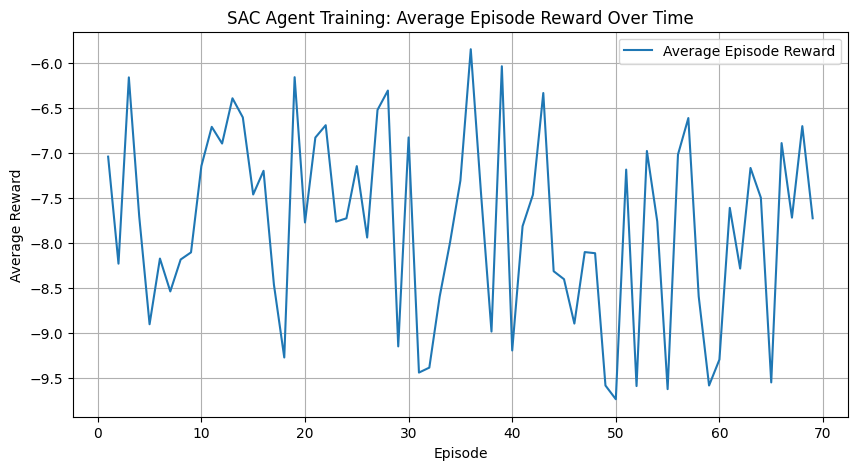

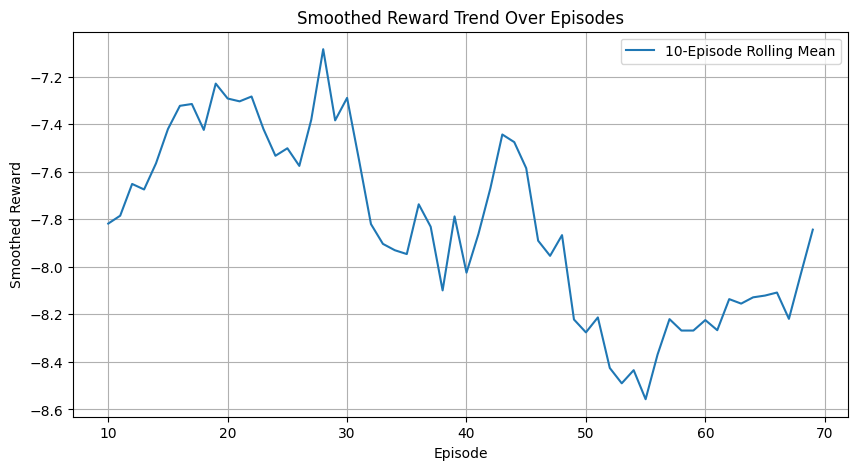

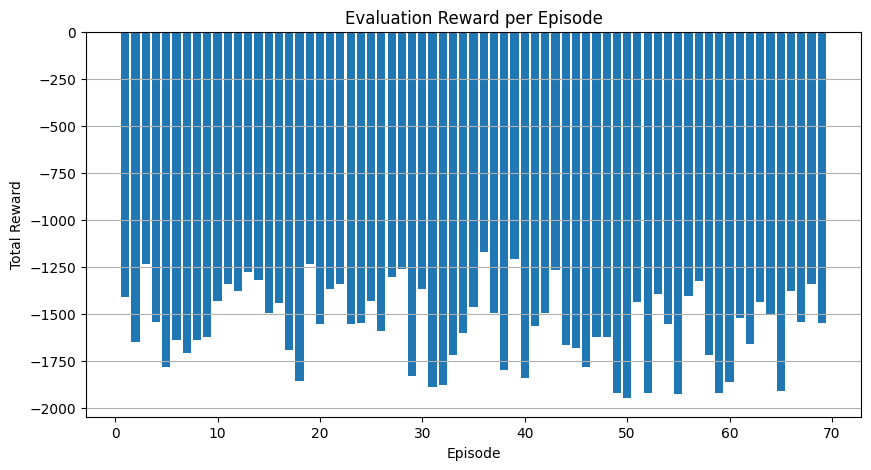

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

episodes = [ep["episode"] for ep in history]
avg_rewards = [ep["avg_reward"] for ep in history]
total_rewards = [ep["total_reward"] for ep in history]


plt.figure(figsize=(10,5))
plt.plot(episodes, avg_rewards, label="Average Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SAC Agent Training: Average Episode Reward Over Time")
plt.legend()
plt.grid(True)
plt.show()

rolling_window = 10
smoothed_rewards = pd.Series(avg_rewards).rolling(window=rolling_window).mean()

plt.figure(figsize=(10,5))
plt.plot(episodes, smoothed_rewards, label=f"{rolling_window}-Episode Rolling Mean")
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.title("Smoothed Reward Trend Over Episodes")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(episodes, total_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Evaluation Reward per Episode")
plt.grid(True, axis="y")
plt.show()

